# 03 — Model Development & Evaluation

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.xgboost
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Load & Split Data

In [2]:
df = pd.read_csv('../data/processed_data.csv')
print('Shape:', df.shape)

# Drop any remaining non-numeric or ID columns
X = df.drop('Churn', axis=1)
y = df['Churn']

# One-hot encode remaining categoricals (Contract, InternetService, PaymentMethod)
X = pd.get_dummies(X, drop_first=True)

print('Features:', X.shape)
print('Target distribution:\n', y.value_counts())

Shape: (7032, 20)
Features: (7032, 23)
Target distribution:
 Churn
0    5163
1    1869
Name: count, dtype: int64


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train:', X_train.shape, '| Test:', X_test.shape)

# Scale — fit on train only, apply to both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Train: (5625, 23) | Test: (1407, 23)


## 2. Evaluate Models

In [4]:
def evaluate_model(model_name, y_test, y_pred, y_prob):
    """Print metrics, confusion matrix, ROC curve, and precision-recall curve."""
    print(f'\n=== {model_name} ===' )
    print(classification_report(y_test, y_pred))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title(f'{model_name} — Confusion Matrix')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[1].plot(fpr, tpr, label=f'AUC = {auc:.4f}', color='#26577C')
    axes[1].plot([0, 1], [0, 1], '--', color='gray')
    axes[1].set_title(f'{model_name} — ROC Curve')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend()

    # Precision-Recall curve
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    axes[2].plot(recall, precision, label=f'AP = {ap:.4f}', color='#E55604')
    axes[2].set_title(f'{model_name} — Precision-Recall Curve')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    return {
        'model': model_name,
        'accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'precision': round(precision_score(y_test, y_pred), 4),
        'recall':    round(recall_score(y_test, y_pred), 4),
        'f1':        round(f1_score(y_test, y_pred), 4),
        'roc_auc':   round(auc, 4),
        'avg_prec':  round(ap, 4)
    }

## 3. Random Forest


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1033
           1       0.57      0.71      0.63       374

    accuracy                           0.78      1407
   macro avg       0.73      0.76      0.74      1407
weighted avg       0.80      0.78      0.79      1407



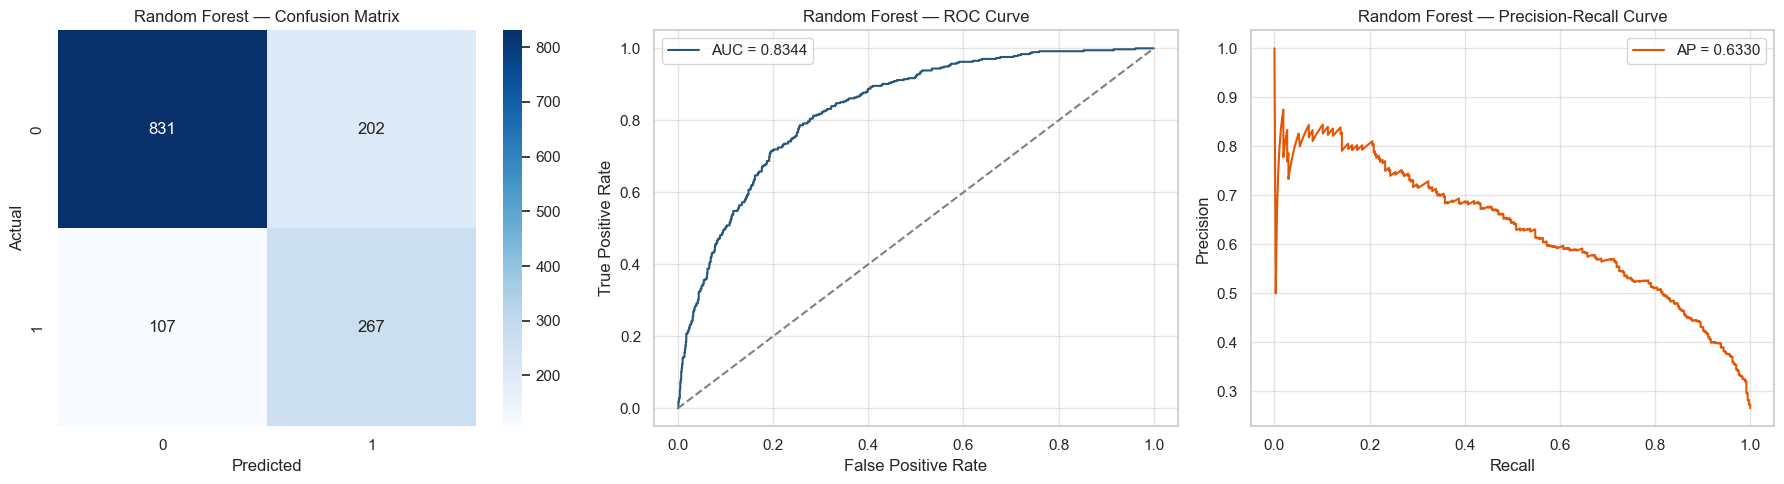

In [5]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)

# RF is tree-based so scaling is not strictly required,
# but we use scaled data for consistency with the scaler artifact.
rf_model.fit(X_train_scaled, y_train)

rf_pred = rf_model.predict(X_test_scaled)
rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

rf_metrics = evaluate_model('Random Forest', y_test, rf_pred, rf_prob)

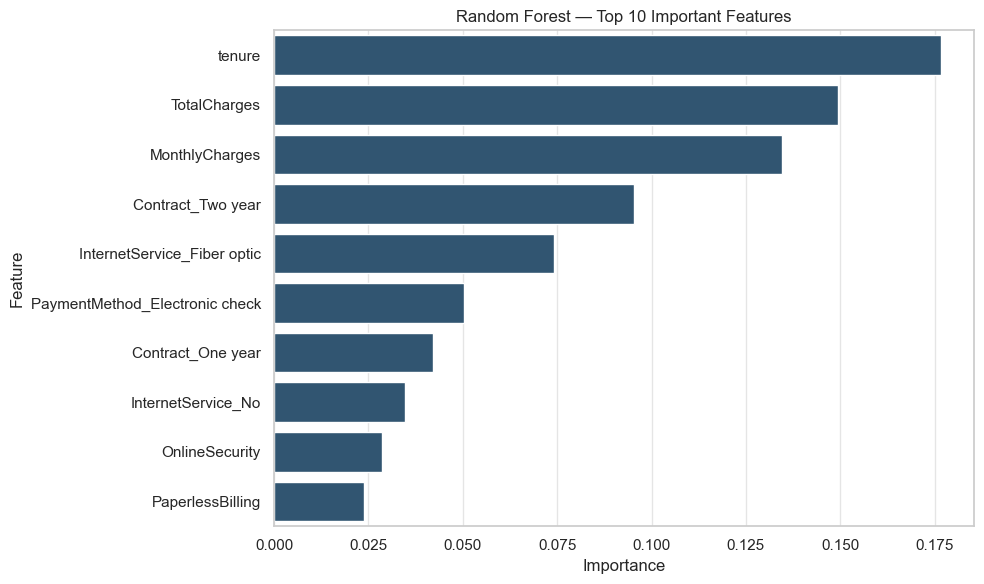

In [6]:
# Feature importance
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=rf_importance.head(10), x='Importance', y='Feature', color='#26577C')
plt.title('Random Forest — Top 10 Important Features')
plt.tight_layout()
plt.show()

## 4. XGBoost


=== XGBoost ===
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.62      0.53      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.78      1407



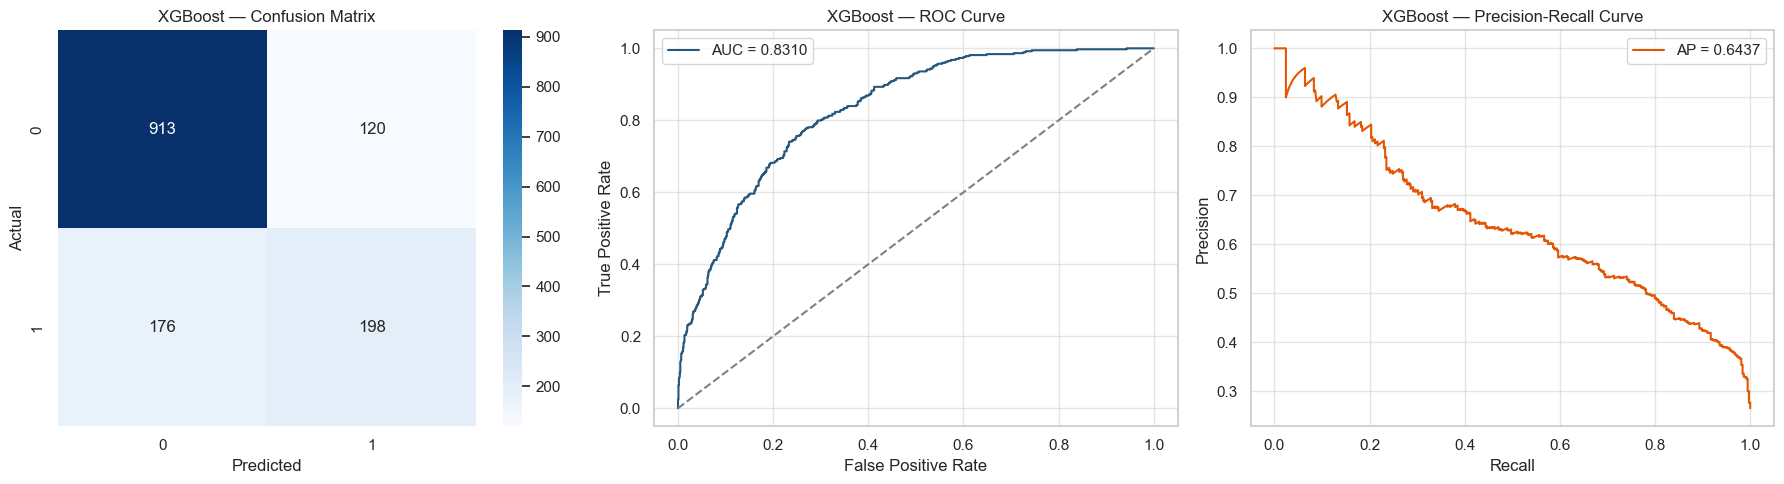

In [7]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

xgb_metrics = evaluate_model('XGBoost', y_test, xgb_pred, xgb_prob)

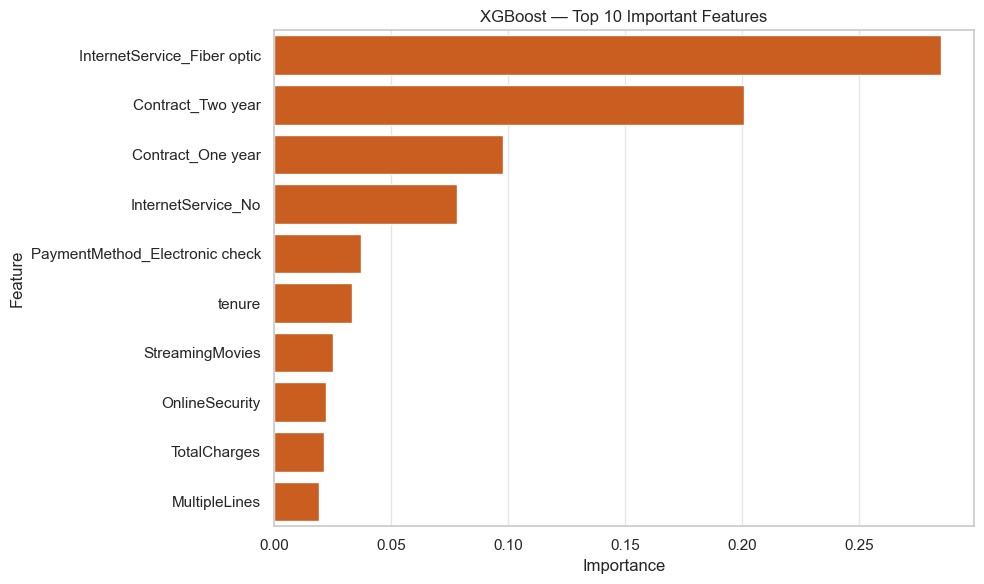

In [8]:
xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=xgb_importance.head(10), x='Importance', y='Feature', color='#E55604')
plt.title('XGBoost — Top 10 Important Features')
plt.tight_layout()
plt.show()

## 5. Model Comparison

In [9]:
comparison_df = pd.DataFrame([rf_metrics, xgb_metrics])
comparison_df = comparison_df.set_index('model')
print(comparison_df.to_string())
comparison_df

               accuracy  precision  recall      f1  roc_auc  avg_prec
model                                                                
Random Forest    0.7804     0.5693  0.7139  0.6335   0.8344    0.6330
XGBoost          0.7896     0.6226  0.5294  0.5723   0.8310    0.6437


,accuracy,precision,recall,f1,roc_auc,avg_prec
model,,,,,,
Random Forest,0.7804,0.5693,0.7139,0.6335,0.8344,0.6330
XGBoost,0.7896,0.6226,0.5294,0.5723,0.8310,0.6437


## 6. Log Both Models to MLflow

In [25]:
mlruns_path = os.path.abspath('../mlruns')
mlflow.set_tracking_uri(f'file:{mlruns_path}')
mlflow.set_registry_uri(f'file:{mlruns_path}/registry')

mlflow.set_experiment('Customer_Churn_Prediction')

# --- Random Forest run ---
with mlflow.start_run(run_name='random_forest_baseline'):
    mlflow.log_param('model', 'RandomForest')
    mlflow.log_param('n_estimators', 500)
    mlflow.log_param('max_depth', 12)
    mlflow.log_param('class_weight', 'balanced')
    for k, v in rf_metrics.items():
        if k != 'model':
            mlflow.log_metric(k, v)

    try:
        from skops.io import dump
    except Exception:
        import sys, subprocess
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'skops'])
        from skops.io import dump

    os.makedirs('../mlruns/rf_model_skops', exist_ok=True)
    rf_skops_path = os.path.join('../mlruns/rf_model_skops', 'model.skops')
    dump(rf_model, rf_skops_path)
    # Log the safe skops artifact to MLflow under the model artifact path
    mlflow.log_artifact(rf_skops_path, artifact_path='random_forest_model')
    mlflow.log_param('model_serialization', 'skops')
    print('Random Forest run logged (skops).')

# --- XGBoost run ---
with mlflow.start_run(run_name='xgboost_baseline'):
    mlflow.log_param('model', 'XGBoost')
    mlflow.log_param('n_estimators', 200)
    mlflow.log_param('learning_rate', 0.05)
    mlflow.log_param('max_depth', 5)
    for k, v in xgb_metrics.items():
        if k != 'model':
            mlflow.log_metric(k, v)


    mlflow.xgboost.log_model(xgb_model, name='xgboost_model')
    print('XGBoost run logged.')

Random Forest run logged (skops).
XGBoost run logged.
